In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
# Dataset
np.random.seed(42)
n = 500

luas = np.random.randint(30, 200, n)
kamar = np.random.randint(1, 5, n)
harga = np.where(luas > 100, luas * 3.5 + kamar * 20, luas * 1.5 + kamar * 10) + np.random.normal(0, 15, n)

df = pd.DataFrame({'Luas': luas, 'Kamar': kamar, 'Harga': harga})

X = df[["Luas", "Kamar"]]
y = df["Harga"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Inisialisasi model
dt_model = DecisionTreeRegressor(random_state=42)

In [46]:
# Pelatihan model untuk membentuk struktur pohon dari Data Latih X_train
dt_model.fit(X_train, y_train)

# Melihat kedalaman pohon dan jumlah daun yang terbentuk secara otomatis dari data
print("Kedalaman Pohon (Depth) :", dt_model.get_depth())
print("Jumlah Daun (Leaves)    :", dt_model.get_n_leaves())

Kedalaman Pohon (Depth) : 13
Jumlah Daun (Leaves)    : 306


In [60]:
# Alur Kerja Lengkap

# ------------------------------------------------------------
# PERSIAPAN DATASET
# ------------------------------------------------------------
np.random.seed(42)
n_samples = 1000

df = pd.DataFrame({
    'Luas_Bangunan': np.random.randint(30, 300, n_samples),
    'Jumlah_Kamar': np.random.randint(1, 6, n_samples),
    'Lokasi': np.random.choice(['Pinggir', 'Kota', 'Pusat'], n_samples),
    'Kondisi': np.random.choice(['Jelek', 'Biasa', 'Bagus'], n_samples),
    'Harga': np.random.randint(200, 2000, n_samples)
})

# ------------------------------------------------------------
# PISAHKAN FITUR DENGAN TARGET
# ------------------------------------------------------------
X = df.drop(columns=["Harga"])
y = df["Harga"]

# ------------------------------------------------------------
# TRAIN TEST SPLIT (80, 20)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_proc = X_train.copy()
X_test_proc = X_test.copy()

# ------------------------------------------------------------
# TRANSFORMASI FITUR ORDINAL (kondisi)
# ------------------------------------------------------------
mapping_kondisi = OrdinalEncoder(categories=[["Jelek", "Biasa", "Bagus"]])
X_train_proc["Kondisi"] = mapping_kondisi.fit_transform(X_train_proc[["Kondisi"]])
X_test_proc["Kondisi"] = mapping_kondisi.transform(X_test_proc[["Kondisi"]])

# ------------------------------------------------------------
# TRANSFORMASI FITUR NOMINAL (lokasi)
# ------------------------------------------------------------
ohe = OneHotEncoder(drop="first", sparse_output=False)
# transform Train
train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train_proc[["Lokasi"]]),
    columns=ohe.get_feature_names_out(["Lokasi"]),
    index=X_train_proc.index
)
X_train_proc = pd.concat([X_train_proc.drop(columns=["Lokasi"]), train_ohe], axis=1)

# Transform Test
test_ohe = pd.DataFrame(
    ohe.transform(X_test_proc[["Lokasi"]]),
    columns=ohe.get_feature_names_out(["Lokasi"]),
    index=X_test_proc.index
)
X_test_proc = pd.concat([X_test_proc.drop(columns=["Lokasi"]), test_ohe], axis=1)

feature_names = list(X_train_proc.columns)

# ------------------------------------------------------------
# TRAINING MODEL
# ------------------------------------------------------------
dt = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train_proc, y_train)

# ------------------------------------------------------------
# PREDIKSI DATA UJI
# ------------------------------------------------------------
y_pred_dt = dt.predict(X_test_proc)

# ------------------------------------------------------------
# EVALUASI MODEL
# ------------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print(f"=== EVALUASI PERFORMA DECISION TREE ===")
print(f"MAE           : {mae:.2f}")
print(f"MSE           : {mse:.2f}")
print(f"RMSE          : {rmse:.2f}")
print(f"R² Score      : {r2:.4f}")

=== EVALUASI PERFORMA DECISION TREE ===
MAE           : 460.11
MSE           : 278966.67
RMSE          : 528.17
R² Score      : -0.0017


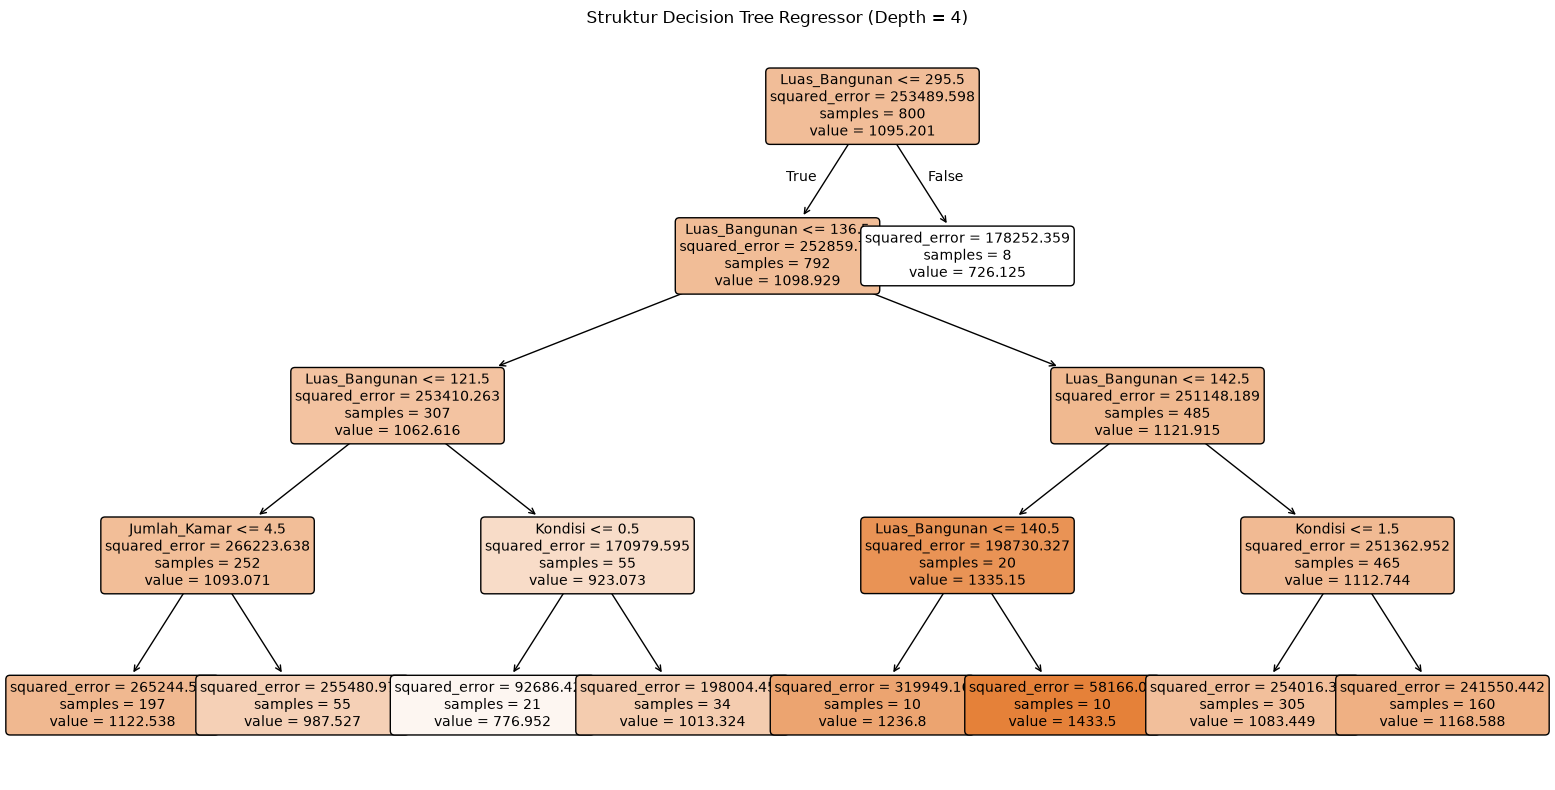

In [61]:
plt.figure(figsize=(16, 8))
plot_tree(
    dt, 
    feature_names=feature_names, 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Struktur Decision Tree Regressor (Depth = 4)")
plt.tight_layout()
plt.show()

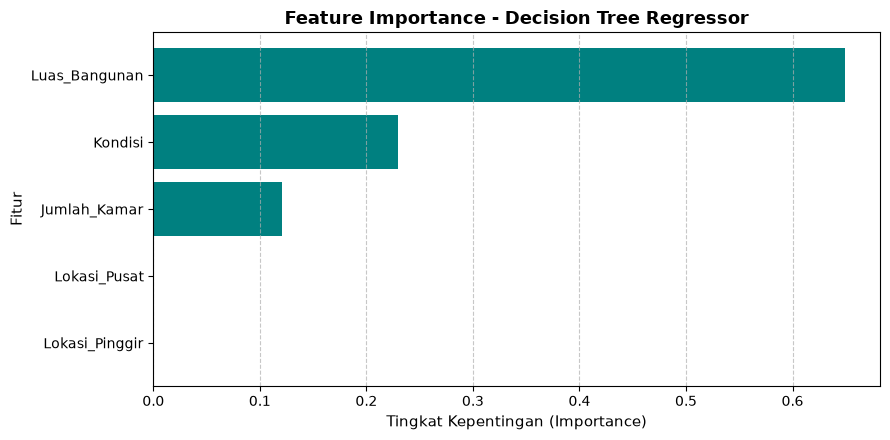

In [62]:
importances = dt.feature_importances_

# Buat DataFrame agar mudah diurutkan dan divisualisasikan
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot Horizontal Bar Chart
plt.figure(figsize=(9, 4.5))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='teal')
plt.xlabel("Tingkat Kepentingan (Importance)", fontsize=11)
plt.ylabel("Fitur", fontsize=11)
plt.title("Feature Importance - Decision Tree Regressor", fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()